# 2. Dynamic multiscale DLinear improvement

The reconstruction showed that our DLinear implementation matches the paper.
We now change only the trend decomposition and keep the dataset, split,
training procedure, forecast horizon, and metrics unchanged.

## 1. Motivation

Original DLinear uses the same moving-average kernel, 25, for every Weather
variable and every input window. Weather contains variables with different
behavior, so one smoothing scale may not be suitable for all of them.

Our question is: **can DLinear improve if the trend scale adapts to both the
variable and the current input window?**

## 2. Two multiscale variants

We use three moving averages:

- kernel 25: about 4.2 hours;
- kernel 73: about 12.2 hours;
- kernel 145: about 24.2 hours.

**Static per-variable multiscale DLinear** learns one fixed softmax mixture for each variable.

**Dynamic per-variable multiscale DLinear**, our final model, also changes the mixture for each input window. A
small gate receives four values for each variable: the window mean, standard
deviation, last value, and last minus first value. The gate output and a
variable-specific prior are passed through softmax, so the three weights are
positive and sum to one.

The weighted trend and remainder are still forecast by DLinear's original
two shared linear layers.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ts_project.data import prepare_weather, build_weather_window_datasets
from ts_project.models import (
    DLinear,
    PerVariableMultiScaleDLinear,
    DynamicPerVariableMultiScaleDLinear,
    initialize_projections_from_dlinear,
)
from ts_project.training import seed_everything, train_forecaster

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "weather.csv"
RESULT_ROOT = PROJECT_ROOT / "results" / "dlinear" / "weather" / "horizon_096"
INPUT_LENGTH = 336
HORIZON = 96
BATCH_SIZE = 16
SEEDS = [2021, 2022, 2023]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


## 3. Model size and a quick implementation check

In [2]:
models = {
    "DLinear": DLinear(input_length=336, prediction_length=96, channels=21),
    "V1": PerVariableMultiScaleDLinear(input_length=336, prediction_length=96, channels=21),
    "V2A": DynamicPerVariableMultiScaleDLinear(input_length=336, prediction_length=96, channels=21),
}
parameter_comparison = pd.DataFrame(
    {
        "Parameters": {
            name: sum(p.numel() for p in model.parameters())
            for name, model in models.items()
        }
    }
)
dlinear_parameters = parameter_comparison.loc["DLinear", "Parameters"]
parameter_comparison["Added vs DLinear"] = (
    parameter_comparison["Parameters"] - dlinear_parameters
)
parameter_comparison["Relative increase vs DLinear (%)"] = 100 * (
    parameter_comparison["Added vs DLinear"] / dlinear_parameters
)
parameter_comparison

,Parameters,Added vs DLinear,Relative increase vs DLinear (%)
DLinear,64704,0,0.000000
V1,64767,63,0.097366
V2A,64834,130,0.200915


In [3]:
example = torch.randn(2, 336, 21)
weights = models["V2A"].scale_weights(example)

print("Forecast shape:", tuple(models["V2A"](example).shape))
print("Weight shape:", tuple(weights.shape))
print("Smallest weight:", weights.min().item())
print("Largest error in weight sums:", (weights.sum(dim=-1) - 1).abs().max().item())

Forecast shape: (2, 96, 21)
Weight shape: (2, 21, 3)
Smallest weight: 0.3333333432674408
Largest error in weight sums: 0.0


The static model adds only 63 parameters, about 0.10% more than DLinear. The dynamic model adds 130
parameters, about 0.20% more than DLinear. The check above also confirms
that every sample and variable receives three valid scale weights.

## 4. Validation-based selection

We now train the static and dynamic multiscale models independently using the official-code seed 2021 and
our additional robustness seeds 2022 and 2023.
Both models use the same split, scaler, optimizer, loss, early stopping, and
metrics as the reconstruction. We compare their validation results before the
test set is evaluated, so test data is not used to choose between them.

In [4]:
weather = prepare_weather(DATA_PATH)
datasets = build_weather_window_datasets(
    weather, input_length=INPUT_LENGTH, prediction_length=HORIZON
)
loaders = {
    "train": DataLoader(datasets["train"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    "validation": DataLoader(datasets["validation"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    "test": DataLoader(datasets["test"], batch_size=BATCH_SIZE, shuffle=False),
}


@torch.inference_mode()
def evaluate_model(model, loader):
    model.eval()
    squared_sum = absolute_sum = 0.0
    count = 0
    for inputs, targets in loader:
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)
        errors = model(inputs) - targets
        squared_sum += errors.square().sum().item()
        absolute_sum += errors.abs().sum().item()
        count += errors.numel()
    return {"mse": squared_sum / count, "mae": absolute_sum / count}


def build_candidate(model_name, seed):
    seed_everything(seed)
    original = DLinear(
        input_length=INPUT_LENGTH,
        prediction_length=HORIZON,
        channels=len(weather.channel_names),
        moving_average=25,
        individual=False,
    )
    seed_everything(seed)
    if model_name == "V1 static multiscale":
        candidate = PerVariableMultiScaleDLinear(
            input_length=INPUT_LENGTH,
            prediction_length=HORIZON,
            channels=len(weather.channel_names),
            kernel_sizes=(25, 73, 145),
        )
    else:
        candidate = DynamicPerVariableMultiScaleDLinear(
            input_length=INPUT_LENGTH,
            prediction_length=HORIZON,
            channels=len(weather.channel_names),
            kernel_sizes=(25, 73, 145),
            hidden_dimension=8,
        )
    initialize_projections_from_dlinear(candidate, original)
    return candidate


trained_models = {}
validation_records = []
training_histories = {}

for model_name in ("V1 static multiscale", "V2A dynamic multiscale"):
    for seed in SEEDS:
        print(f"\n===== {model_name} | seed {seed} =====")
        model = build_candidate(model_name, seed)
        seed_everything(seed)
        training = train_forecaster(
            model,
            loaders["train"],
            loaders["validation"],
            device=DEVICE,
            learning_rate=1e-4,
            max_epochs=10,
            patience=3,
            verbose=True,
        )
        metrics = evaluate_model(model, loaders["validation"])
        validation_records.append(
            {
                "seed": seed,
                "model": model_name,
                "val_mse": metrics["mse"],
                "val_mae": metrics["mae"],
                "best_epoch": training.best_epoch,
                "parameters": sum(p.numel() for p in model.parameters()),
            }
        )
        training_histories[(model_name, seed)] = pd.DataFrame(training.history)
        trained_models[(model_name, seed)] = model.cpu()

validation = pd.DataFrame(validation_records)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
validation.to_csv(RESULT_ROOT / "validation_by_seed.csv", index=False)
validation


===== V1 static multiscale | seed 2021 =====
Epoch   1/10 | train MSE 0.499450 | validation MSE 0.425277 | lr 1.00e-04
Epoch   2/10 | train MSE 0.457009 | validation MSE 0.411308 | lr 1.00e-04
Epoch   3/10 | train MSE 0.444406 | validation MSE 0.403970 | lr 5.00e-05
Epoch   4/10 | train MSE 0.440020 | validation MSE 0.401955 | lr 2.50e-05
Epoch   5/10 | train MSE 0.438352 | validation MSE 0.402352 | lr 1.25e-05
Epoch   6/10 | train MSE 0.437527 | validation MSE 0.400042 | lr 6.25e-06
Epoch   7/10 | train MSE 0.437124 | validation MSE 0.400096 | lr 3.13e-06
Epoch   8/10 | train MSE 0.436942 | validation MSE 0.400040 | lr 1.56e-06
Epoch   9/10 | train MSE 0.435938 | validation MSE 0.400299 | lr 7.81e-07
Epoch  10/10 | train MSE 0.436760 | validation MSE 0.400142 | lr 3.91e-07

===== V1 static multiscale | seed 2022 =====
Epoch   1/10 | train MSE 0.497824 | validation MSE 0.429604 | lr 1.00e-04
Epoch   2/10 | train MSE 0.457467 | validation MSE 0.408696 | lr 1.00e-04
Epoch   3/10 | train

,seed,model,val_mse,val_mae,best_epoch,parameters
0,2021,V1 static multiscale,0.400249,0.294227,8,64767
1,2022,V1 static multiscale,0.399301,0.294250,5,64767
2,2023,V1 static multiscale,0.399240,0.293738,9,64767
3,2021,V2A dynamic multiscale,0.390399,0.289043,6,64834
4,2022,V2A dynamic multiscale,0.388505,0.289105,5,64834
5,2023,V2A dynamic multiscale,0.388321,0.288296,9,64834


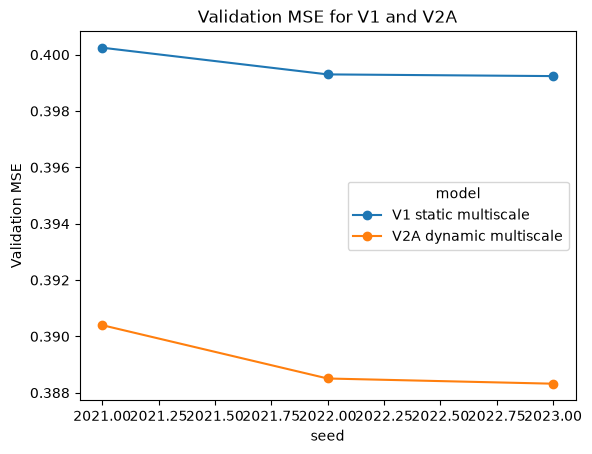

In [5]:
validation.pivot(index="seed", columns="model", values="val_mse").plot(
    marker="o",
    ylabel="Validation MSE",
    title="Validation MSE for V1 and V2A",
)
plt.show()

Dynamic per-variable multiscale DLinear improves validation MSE and MAE for all three seeds, so we selected it
as the final architecture before evaluating its test checkpoints.

## 5. Final test results

The dynamic model has now been selected using validation data. We evaluate the saved static and
dynamic validation-selected checkpoints on the test set. The static model remains in the table as
an ablation, not as a candidate selected using test performance.

In [6]:
test_records = []
for (model_name, seed), model in trained_models.items():
    model = model.to(DEVICE)
    metrics = evaluate_model(model, loaders["test"])
    test_records.append(
        {
            "seed": seed,
            "model": model_name,
            "test_mse": metrics["mse"],
            "test_mae": metrics["mae"],
            "parameters": sum(p.numel() for p in model.parameters()),
        }
    )
    trained_models[(model_name, seed)] = model.cpu()

test_by_seed = pd.DataFrame(test_records)
test_summary = test_by_seed.groupby("model", as_index=False).agg(
    test_mse_mean=("test_mse", "mean"),
    test_mse_std=("test_mse", "std"),
    test_mae_mean=("test_mae", "mean"),
    test_mae_std=("test_mae", "std"),
)
test_by_seed.to_csv(RESULT_ROOT / "improvement_test_by_seed.csv", index=False)
test_summary.to_csv(RESULT_ROOT / "improvement_test_summary.csv", index=False)
display(test_by_seed)
display(test_summary)

,seed,model,test_mse,test_mae,parameters
0,2021,V1 static multiscale,0.167234,0.228547,64767
1,2022,V1 static multiscale,0.167883,0.230407,64767
2,2023,V1 static multiscale,0.167048,0.228346,64767
3,2021,V2A dynamic multiscale,0.164952,0.223527,64834
4,2022,V2A dynamic multiscale,0.165861,0.226255,64834
5,2023,V2A dynamic multiscale,0.165394,0.224983,64834


,model,test_mse_mean,test_mse_std,test_mae_mean,test_mae_std
0,V1 static multiscale,0.167388,0.000438,0.229100,0.001136
1,V2A dynamic multiscale,0.165403,0.000455,0.224922,0.001365


In [7]:
reconstruction_path = RESULT_ROOT / "reconstruction_by_seed.csv"
if not reconstruction_path.exists():
    raise FileNotFoundError("Run notebook 1 before creating the final comparison.")
dlinear_runs = pd.read_csv(reconstruction_path)

def candidate_row(model_name):
    row = test_summary.loc[test_summary["model"] == model_name].iloc[0]
    parameter_count = test_by_seed.loc[test_by_seed["model"] == model_name, "parameters"].iloc[0]
    return {"Model": model_name, "MSE": row["test_mse_mean"], "MAE": row["test_mae_mean"], "Parameters": parameter_count}

final_comparison = pd.DataFrame(
    [
        {"Model": "Paper DLinear", "MSE": 0.176, "MAE": 0.237, "Parameters": np.nan},
        {"Model": "Seasonal naive", "MSE": 0.3167066, "MAE": 0.2879560, "Parameters": 0},
        {"Model": "Our DLinear", "MSE": dlinear_runs["test_mse"].mean(), "MAE": dlinear_runs["test_mae"].mean(), "Parameters": int(dlinear_runs["parameters"].iloc[0])},
        candidate_row("V1 static multiscale"),
        candidate_row("V2A dynamic multiscale"),
    ]
)
final_comparison["RMSE"] = np.sqrt(final_comparison["MSE"])
final_comparison

,Model,MSE,MAE,Parameters,RMSE
0,Paper DLinear,0.176000,0.237000,NaN,0.419524
1,Seasonal naive,0.316707,0.287956,0.0,0.562767
2,Our DLinear,0.174638,0.234864,64704.0,0.417897
3,V1 static multiscale,0.167388,0.229100,64767.0,0.409131
4,V2A dynamic multiscale,0.165403,0.224922,64834.0,0.406697


Across the three paired seeds, dynamic per-variable multiscale DLinear reduces test MSE by about 5.29% and MAE
by about 4.23% compared with reconstructed DLinear. It wins on both metrics
for all three seeds.

## 6. Conclusion and limitations

The results support our hypothesis on Weather: variable-specific scales help,
and adapting them to the current input window helps further. Static per-variable
multiscale DLinear reduces paired MSE by 4.15%, while the selected dynamic model
reduces MSE by 5.29% and MAE by 4.23%. It wins on both metrics for all three
paired seeds while adding only 130 parameters, or about 0.20%, to DLinear.

The result should not be described as a universal improvement because this
experiment uses one dataset, one input length, and one forecast horizon. Within
that scope, the validation-based selection and consistent paired-seed wins provide
strong evidence that adaptive multiscale decomposition improves DLinear.